# Analyzing global internet patterns

## 📖 Background
In this competition, you'll be exploring a dataset that highlights internet usage for different countries from 2000 to 2023. Your goal is import, clean, analyze and visualize the data in your preferred tool.

The end goal will be a clean, self explanatory, and interactive visualization. By conducting a thorough analysis, you'll dive deeper into how internet usage has changed over time and the countries still widely impacted by lack of internet availability. 


## 💾 Data

#### You have access to the following file, but you can supplement your data with other sources to enrich your analysis. 

### Interet Usage (`internet_usage.csv`)
|   Column name  |   Description | 
|---------------|-----------|
| Country Name | Name of the country |
| Country Code | Countries 3 character country code|
| 2000 | Contains the % of population of individuals using the internet in 2000  |
| 2001 | Contains the % of population of individuals using the internet in 2001  |
| 2002 | Contains the % of population of individuals using the internet in 2002  |
| 2003 | Contains the % of population of individuals using the internet in 2003  |
| .... | ...  |
| 2023 | Contains the % of population of individuals using the internet in 2023  |

**The data can be downloaded from the _Files_ section (_File_ > _Show workbook files_).**

## 💪 Challenge
Use a tool of your choice to create an interesting visual or dashboard that summarizes your analysis! 

Things to consider:
1. Use this Workspace to prepare your data (optional).
2. Stuck on where to start, here's some ideas to get you started: 
    - Visualize interner usage over time, by country 
    - How has internet usage changed over time, are there any patterns emerging? 
    - Consider bringing in other data to supplement your analysis 
3. Create a screenshot of your main dashboard / visuals, and paste in the designated field. 
4. Summarize your findings in an executive summary.

### importing the data

In [67]:
import pandas as pd

# Load the dataset
data = pd.read_csv('internet_usage.csv')

# Preview the data
data.head()


,Country Name,Country Code,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Afghanistan,AFG,..,0.00472257,0.0045614,0.0878913,0.105809,1.22415,2.10712,1.9,...,7,8.26,11,13.5,16.8,17.6,18.4,..,..,..
1,Albania,ALB,0.114097,0.325798,0.390081,0.9719,2.42039,6.04389,9.60999,15.0361,...,54.3,56.9,59.6,62.4,65.4,68.5504,72.2377,79.3237,82.6137,83.1356
2,Algeria,DZA,0.491706,0.646114,1.59164,2.19536,4.63448,5.84394,7.37598,9.45119,...,29.5,38.2,42.9455,47.6911,49.0385,58.9776,60.6534,66.2356,71.2432,..
3,American Samoa,ASM,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
4,Andorra,AND,10.5388,..,11.2605,13.5464,26.838,37.6058,48.9368,70.87,...,86.1,87.9,89.7,91.5675,..,90.7187,93.2056,93.8975,94.4855,..


In [68]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country Name  217 non-null    object
 1   Country Code  217 non-null    object
 2   2000          217 non-null    object
 3   2001          217 non-null    object
 4   2002          217 non-null    object
 5   2003          217 non-null    object
 6   2004          217 non-null    object
 7   2005          217 non-null    object
 8   2006          217 non-null    object
 9   2007          217 non-null    object
 10  2008          217 non-null    object
 11  2009          217 non-null    object
 12  2010          217 non-null    object
 13  2011          217 non-null    object
 14  2012          217 non-null    object
 15  2013          217 non-null    object
 16  2014          217 non-null    object
 17  2015          217 non-null    object
 18  2016          217 non-null    object
 19  2017    

## Data Preprocessing


### 1. Clean and Handle Missing Values
We need to clean the dataset and handle missing values.

In [69]:
import numpy as np

# Drop 'Country Code' and set 'Country Name' as index
data_clean = data.drop(['Country Code'], axis=1).set_index('Country Name')

# Replace any '..' with NaN and convert to float
for col in data_clean.columns:
    data_clean[col] = data_clean[col].replace('..', np.nan).astype('float16')

# Check for missing values
missing_values = data_clean.isna().sum()
print(missing_values)


2000     21
2001     18
2002     15
2003     21
2004     18
2005     17
2006     18
2007     13
2008     15
2009     15
2010     16
2011     13
2012     15
2013     16
2014     16
2015     17
2016     14
2017     11
2018     41
2019     31
2020     25
2021     27
2022     34
2023    158
dtype: int64


### 2. Handle Missing Values


In [70]:
data_clean = data_clean.interpolate(method='linear', axis=0)
data_clean = data_clean.fillna(data_clean.mean()) # because very few values still there

# print(data_clean.isna().sum())

# Exploratory Data Analysis (EDA)

### 1. Visualizing Global Internet Growth (Line Chart)


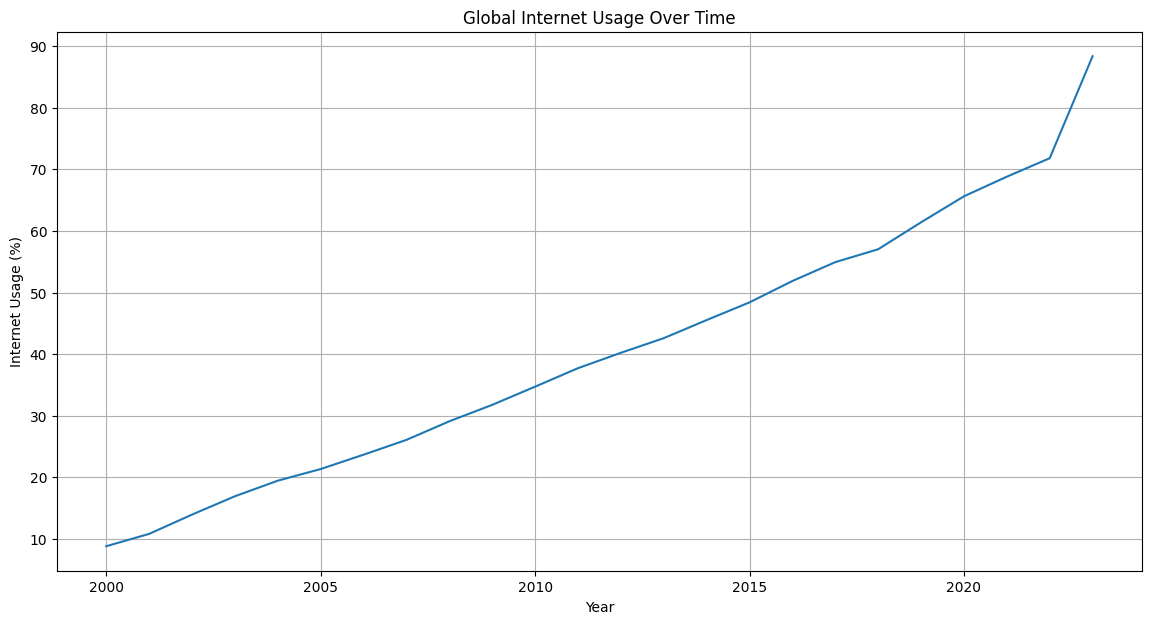

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot global internet usage over time
plt.figure(figsize=(14, 7))
data_clean.T.mean(axis=1).plot()  # Average across all countries
plt.title("Global Internet Usage Over Time")
plt.xlabel("Year")
plt.ylabel("Internet Usage (%)")
plt.grid(True)
plt.show()


- > take away : internet usage increase linearly over time and exposure near to 2022/2023 

### 2. Visualizing by Country (Individual Country Trend)



In [72]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

# List of available countries (assuming data_clean contains this list)
countries = data_clean.index.tolist()

# Define the interactive plot function
def plot_internet_usage(country):
    plt.figure(figsize=(14, 7))
    data_clean.loc[country].plot()
    plt.title(f"Internet Usage in {country} Over Time")
    plt.xlabel("Year")
    plt.ylabel("Internet Usage (%)")
    plt.grid(True)
    plt.show()

# Create the interactive widget
interact(plot_internet_usage, country=widgets.Dropdown(
    options=countries, 
    description='Country:', 
    style={'description_width': 'initial'}
))


interactive(children=(Dropdown(description='Country:', options=('Afghanistan', 'Albania', 'Algeria', 'American…

<function __main__.plot_internet_usage(country)>

### 3. Average Internet Usage by Continent (more data collected from internet and added manually)

add continent column to the data

In [73]:
country_to_continent = {
    'Afghanistan': 'Asia', 'Albania': 'Europe', 'Algeria': 'Africa', 'American Samoa': 'Oceania', 'Andorra': 'Europe', 'Angola': 'Africa', 
    'Antigua and Barbuda': 'North America', 'Argentina': 'South America', 'Armenia': 'Asia', 'Aruba': 'North America', 'Australia': 'Oceania',
    'Austria': 'Europe', 'Azerbaijan': 'Asia', 'Bahamas, The': 'North America', 'Bahrain': 'Asia', 'Bangladesh': 'Asia', 'Barbados': 'North America',
    'Belarus': 'Europe', 'Belgium': 'Europe', 'Belize': 'North America', 'Benin': 'Africa', 'Bermuda': 'North America', 'Bhutan': 'Asia', 
    'Bolivia': 'South America', 'Bosnia and Herzegovina': 'Europe', 'Botswana': 'Africa', 'Brazil': 'South America', 'British Virgin Islands': 'North America',
    'Brunei Darussalam': 'Asia', 'Bulgaria': 'Europe', 'Burkina Faso': 'Africa', 'Burundi': 'Africa', 'Cabo Verde': 'Africa', 'Cambodia': 'Asia',
    'Cameroon': 'Africa', 'Canada': 'North America', 'Cayman Islands': 'North America', 'Central African Republic': 'Africa', 'Chad': 'Africa', 
    'Channel Islands': 'Europe', 'Chile': 'South America', 'China': 'Asia', 'Colombia': 'South America', 'Comoros': 'Africa', 'Congo, Dem. Rep.': 'Africa',
    'Congo, Rep.': 'Africa', 'Costa Rica': 'North America', 'Cote d\'Ivoire': 'Africa', 'Croatia': 'Europe', 'Cuba': 'North America', 'Curacao': 'North America',
    'Cyprus': 'Europe', 'Czechia': 'Europe', 'Denmark': 'Europe', 'Djibouti': 'Africa', 'Dominica': 'North America', 'Dominican Republic': 'North America',
    'Ecuador': 'South America', 'Egypt, Arab Rep.': 'Africa', 'El Salvador': 'North America', 'Equatorial Guinea': 'Africa', 'Eritrea': 'Africa', 
    'Estonia': 'Europe', 'Eswatini': 'Africa', 'Ethiopia': 'Africa', 'Faroe Islands': 'Europe', 'Fiji': 'Oceania', 'Finland': 'Europe', 'France': 'Europe', 
    'French Polynesia': 'Oceania', 'Gabon': 'Africa', 'Gambia, The': 'Africa', 'Georgia': 'Asia', 'Germany': 'Europe', 'Ghana': 'Africa', 'Gibraltar': 'Europe', 
    'Greece': 'Europe', 'Greenland': 'North America', 'Grenada': 'North America', 'Guam': 'Oceania', 'Guatemala': 'North America', 'Guinea': 'Africa', 
    'Guinea-Bissau': 'Africa', 'Guyana': 'South America', 'Haiti': 'North America', 'Honduras': 'North America', 'Hong Kong SAR, China': 'Asia', 'Hungary': 'Europe',
    'Iceland': 'Europe', 'India': 'Asia', 'Indonesia': 'Asia', 'Iran, Islamic Rep.': 'Asia', 'Iraq': 'Asia', 'Ireland': 'Europe', 'Isle of Man': 'Europe',
    'Israel': 'Asia', 'Italy': 'Europe', 'Jamaica': 'North America', 'Japan': 'Asia', 'Jordan': 'Asia', 'Kazakhstan': 'Asia', 'Kenya': 'Africa', 'Kiribati': 'Oceania',
    'Korea, Dem. People\'s Rep.': 'Asia', 'Korea, Rep.': 'Asia', 'Kosovo': 'Europe', 'Kuwait': 'Asia', 'Kyrgyz Republic': 'Asia', 'Lao PDR': 'Asia', 'Latvia': 'Europe',
    'Lebanon': 'Asia', 'Lesotho': 'Africa', 'Liberia': 'Africa', 'Libya': 'Africa', 'Liechtenstein': 'Europe', 'Lithuania': 'Europe', 'Luxembourg': 'Europe', 
    'Macao SAR, China': 'Asia', 'Madagascar': 'Africa', 'Malawi': 'Africa', 'Malaysia': 'Asia', 'Maldives': 'Asia', 'Mali': 'Africa', 'Malta': 'Europe', 
    'Marshall Islands': 'Oceania', 'Mauritania': 'Africa', 'Mauritius': 'Africa', 'Mexico': 'North America', 'Micronesia, Fed. Sts.': 'Oceania', 'Moldova': 'Europe', 
    'Monaco': 'Europe', 'Mongolia': 'Asia', 'Montenegro': 'Europe', 'Morocco': 'Africa', 'Mozambique': 'Africa', 'Myanmar': 'Asia', 'Namibia': 'Africa', 
    'Nauru': 'Oceania', 'Nepal': 'Asia', 'Netherlands': 'Europe', 'New Caledonia': 'Oceania', 'New Zealand': 'Oceania', 'Nicaragua': 'North America', 'Niger': 'Africa', 
    'Nigeria': 'Africa', 'North Macedonia': 'Europe', 'Northern Mariana Islands': 'Oceania', 'Norway': 'Europe', 'Oman': 'Asia', 'Pakistan': 'Asia', 
    'Palau': 'Oceania', 'Panama': 'North America', 'Papua New Guinea': 'Oceania', 'Paraguay': 'South America', 'Peru': 'South America', 'Philippines': 'Asia',
    'Poland': 'Europe', 'Portugal': 'Europe', 'Puerto Rico': 'North America', 'Qatar': 'Asia', 'Romania': 'Europe', 'Russian Federation': 'Europe', 
    'Rwanda': 'Africa', 'Samoa': 'Oceania', 'San Marino': 'Europe', 'Sao Tome and Principe': 'Africa', 'Saudi Arabia': 'Asia', 'Senegal': 'Africa', 'Serbia': 'Europe',
    'Seychelles': 'Africa', 'Sierra Leone': 'Africa', 'Singapore': 'Asia', 'Sint Maarten (Dutch part)': 'North America', 'Slovak Republic': 'Europe', 
    'Slovenia': 'Europe', 'Solomon Islands': 'Oceania', 'Somalia': 'Africa', 'South Africa': 'Africa', 'South Sudan': 'Africa', 'Spain': 'Europe', 'Sri Lanka': 'Asia', 
    'St. Kitts and Nevis': 'North America', 'St. Lucia': 'North America', 'St. Martin (French part)': 'North America', 'St. Vincent and the Grenadines': 'North America',
    'Sudan': 'Africa', 'Suriname': 'South America', 'Sweden': 'Europe', 'Switzerland': 'Europe', 'Syrian Arab Republic': 'Asia', 'Tajikistan': 'Asia', 'Tanzania': 'Africa', 
    'Thailand': 'Asia', 'Timor-Leste': 'Asia', 'Togo': 'Africa', 'Tonga': 'Oceania', 'Trinidad and Tobago': 'North America', 'Tunisia': 'Africa', 'Turkiye': 'Asia', 
    'Turkmenistan': 'Asia', 'Turks and Caicos Islands': 'North America', 'Tuvalu': 'Oceania', 'Uganda': 'Africa', 'Ukraine': 'Europe', 'United Arab Emirates': 'Asia', 
    'United Kingdom': 'Europe', 'United States': 'North America', 'Uruguay': 'South America', 'Uzbekistan': 'Asia', 'Vanuatu': 'Oceania', 'Venezuela, RB': 'South America',
    'Viet Nam': 'Asia', 'Virgin Islands (U.S.)': 'North America', 'West Bank and Gaza': 'Asia', 'Yemen, Rep.': 'Asia', 'Zambia': 'Africa', 'Zimbabwe': 'Africa'
}

# Apply the mapping
data_clean = data_clean.reset_index()
data_clean['Continent'] = data_clean['Country Name'].map(country_to_continent)
data_clean = data_clean.set_index('Country Name')


Visualizing Average Internet Usage by Continent

C:\Users\El-Wattaneya\AppData\Local\Temp\ipykernel_480\777361875.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(continents))  # Get unique colors


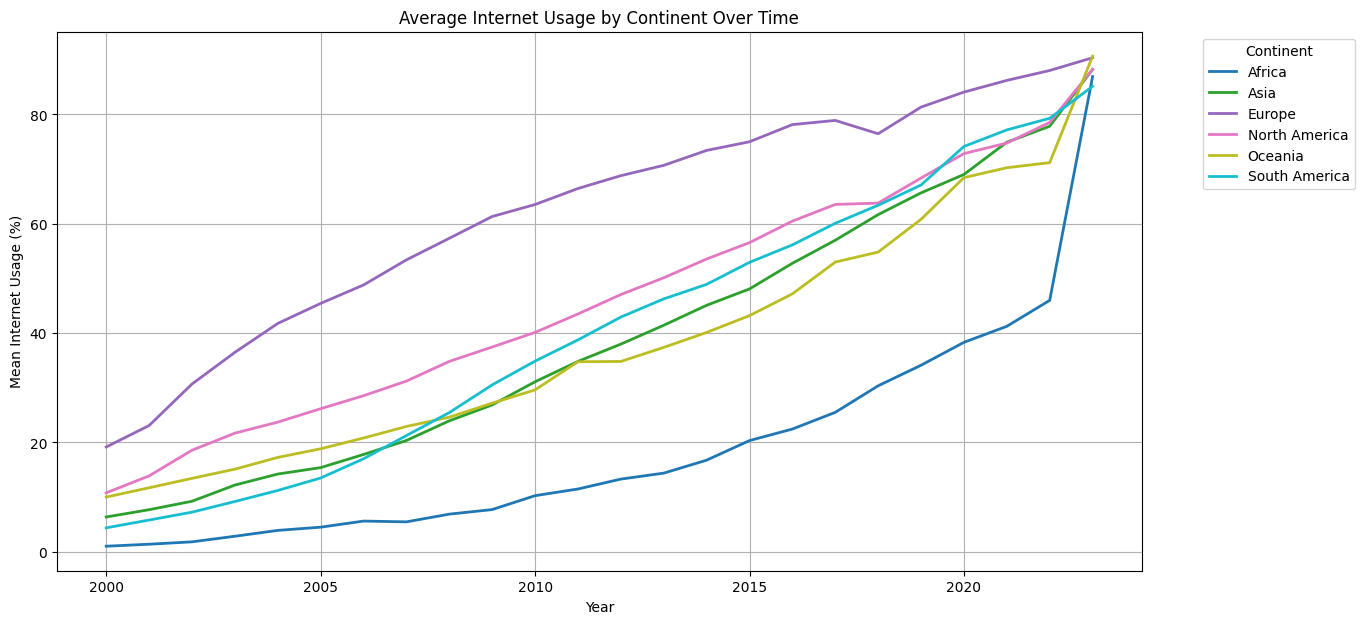

In [74]:
import matplotlib.pyplot as plt
import pandas as pd

# Reset index to make 'Country Name' a column
data_clean_reset = data_clean.reset_index()

# Convert wide format to long format
data_long = data_clean_reset.melt(id_vars=['Country Name', 'Continent'], 
                                  var_name='Year', 
                                  value_name='Internet Usage (%)')

# Convert 'Year' to integer for proper sorting
data_long['Year'] = data_long['Year'].astype(int)

# Compute the mean internet usage per continent per year
continent_mean = data_long.groupby(['Continent', 'Year'])['Internet Usage (%)'].mean().reset_index()

# Assign a unique color for each continent
continents = continent_mean['Continent'].unique()
colors = plt.cm.get_cmap('tab10', len(continents))  # Get unique colors
continent_colors = {continent: colors(i) for i, continent in enumerate(continents)}

# Plot mean internet usage per continent
plt.figure(figsize=(14, 7))
for continent in continents:
    subset = continent_mean[continent_mean['Continent'] == continent]
    plt.plot(subset['Year'], subset['Internet Usage (%)'], 
             label=continent, color=continent_colors[continent], linewidth=2)

# Customize the plot
plt.title('Average Internet Usage by Continent Over Time')
plt.xlabel('Year')
plt.ylabel('Mean Internet Usage (%)')
plt.legend(title='Continent', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


- > Take away : the trend for continents is similar with high internet usage spread for Europe and low internet usage spread for Africa

### 4. Heatmap of Internet Usage by Country and Year

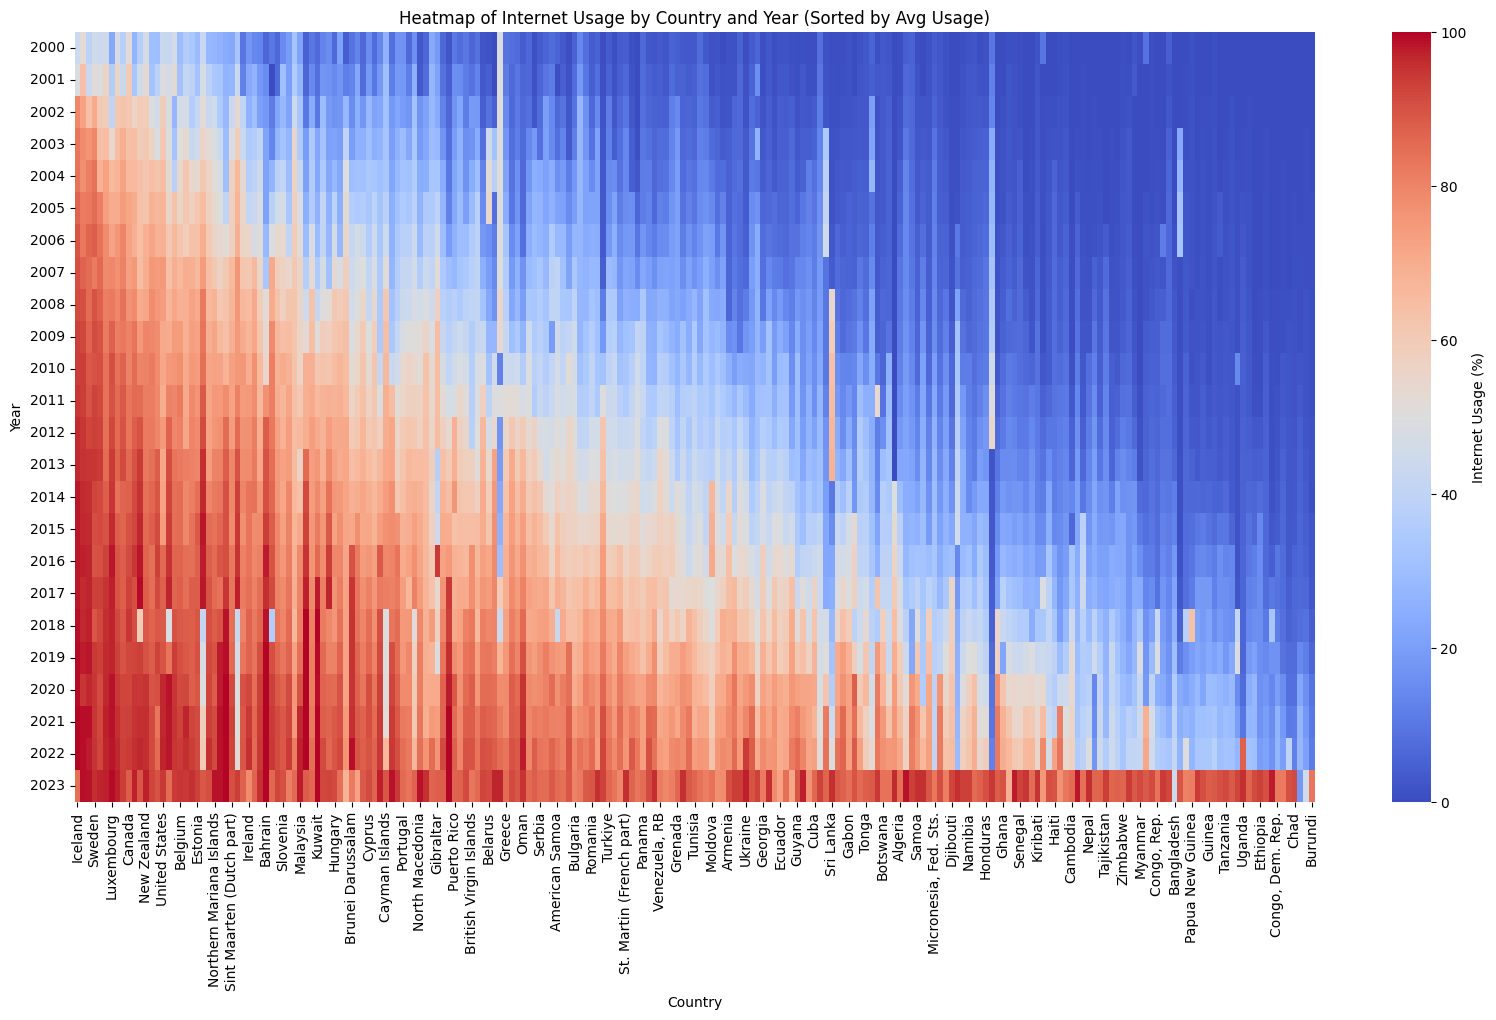

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

data_clean= data_clean.drop('Continent', axis=1)

# Compute the average internet usage for each country
country_mean_usage = data_clean.mean(axis=1).sort_values(ascending=False)

# Sort the dataframe by the computed average
data_sorted = data_clean.loc[country_mean_usage.index]

# Plot the sorted heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(data_sorted.T, cmap='coolwarm', cbar_kws={'label': 'Internet Usage (%)'})

# Customize the plot
plt.title('Heatmap of Internet Usage by Country and Year (Sorted by Avg Usage)')
plt.xlabel('Country')
plt.ylabel('Year')
plt.show()


- > This increase our assumtion that internet usage increases over time and explodes near to 2022/2023 AND this also shows that this increase of internet usage happened to some counties more(and faster) than others

# Advanced Analysis - Clustering & Patterns

## 1. KMeans Clustering


### We can cluster countries into groups based on their internet usage patterns.



elbow plot to show how many clusters we can put the countries in

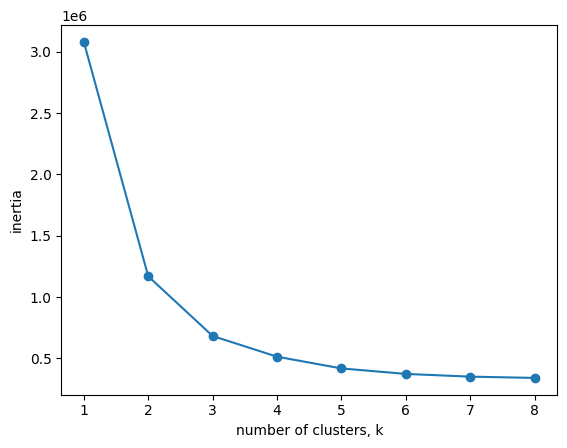

In [76]:
import numpy as np
from sklearn.cluster import KMeans

samples = np.array(data_clean)

ks = range(1, 9)
inertias = []

for k in ks:
    # Create a KMeans instance with k clusters: model
    model = KMeans(n_clusters=k)
    
    # Fit model to samples
    model.fit(samples)
    
    # Append the inertia to the list of inertias
    inertias.append(model.inertia_)
    
# Plot ks vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()


- > we can cluster the countries to 4 or 6 clusters based in thier similarity in internet usage

In [77]:

# Prepare data for clustering
samples = data_clean.values  

# Apply KMeans clustering
kmeans = KMeans(n_clusters=4)
labels = kmeans.fit_predict(samples)

# Create a DataFrame with labels and country names
df_cluster = pd.DataFrame({'Country': data_clean.index, 'Cluster': labels})
df_cluster = df_cluster.sort_values('Cluster')
print(df_cluster)


                   Country  Cluster
0              Afghanistan        0
128  Micronesia, Fed. Sts.        0
125             Mauritania        0
122                   Mali        0
119                 Malawi        0
..                     ...      ...
10               Australia        3
141            New Zealand        3
88                 Iceland        3
35                  Canada        3
18                 Belgium        3

[217 rows x 2 columns]


In [78]:
print(df_cluster[df_cluster['Cluster']==0][:5], '\n----------------------------------------')
print(df_cluster[df_cluster['Cluster']==1][:5], '\n----------------------------------------')
print(df_cluster[df_cluster['Cluster']==2][:5], '\n----------------------------------------')
print(df_cluster[df_cluster['Cluster']==3][:5], '\n----------------------------------------')

                   Country  Cluster
0              Afghanistan        0
128  Micronesia, Fed. Sts.        0
125             Mauritania        0
122                   Mali        0
119                 Malawi        0 
----------------------------------------
               Country  Cluster
174           Slovenia        1
7            Argentina        1
28   Brunei Darussalam        1
133            Morocco        1
132         Montenegro        1 
----------------------------------------
                            Country  Cluster
124                Marshall Islands        2
186                        Suriname        2
184  St. Vincent and the Grenadines        2
183        St. Martin (French part)        2
182                       St. Lucia        2 
----------------------------------------
            Country  Cluster
53          Denmark        3
116      Luxembourg        3
206   United States        3
205  United Kingdom        3
105          Kosovo        3 
---------------------

## 2. Hierarchical Clustering (Dendrogram)



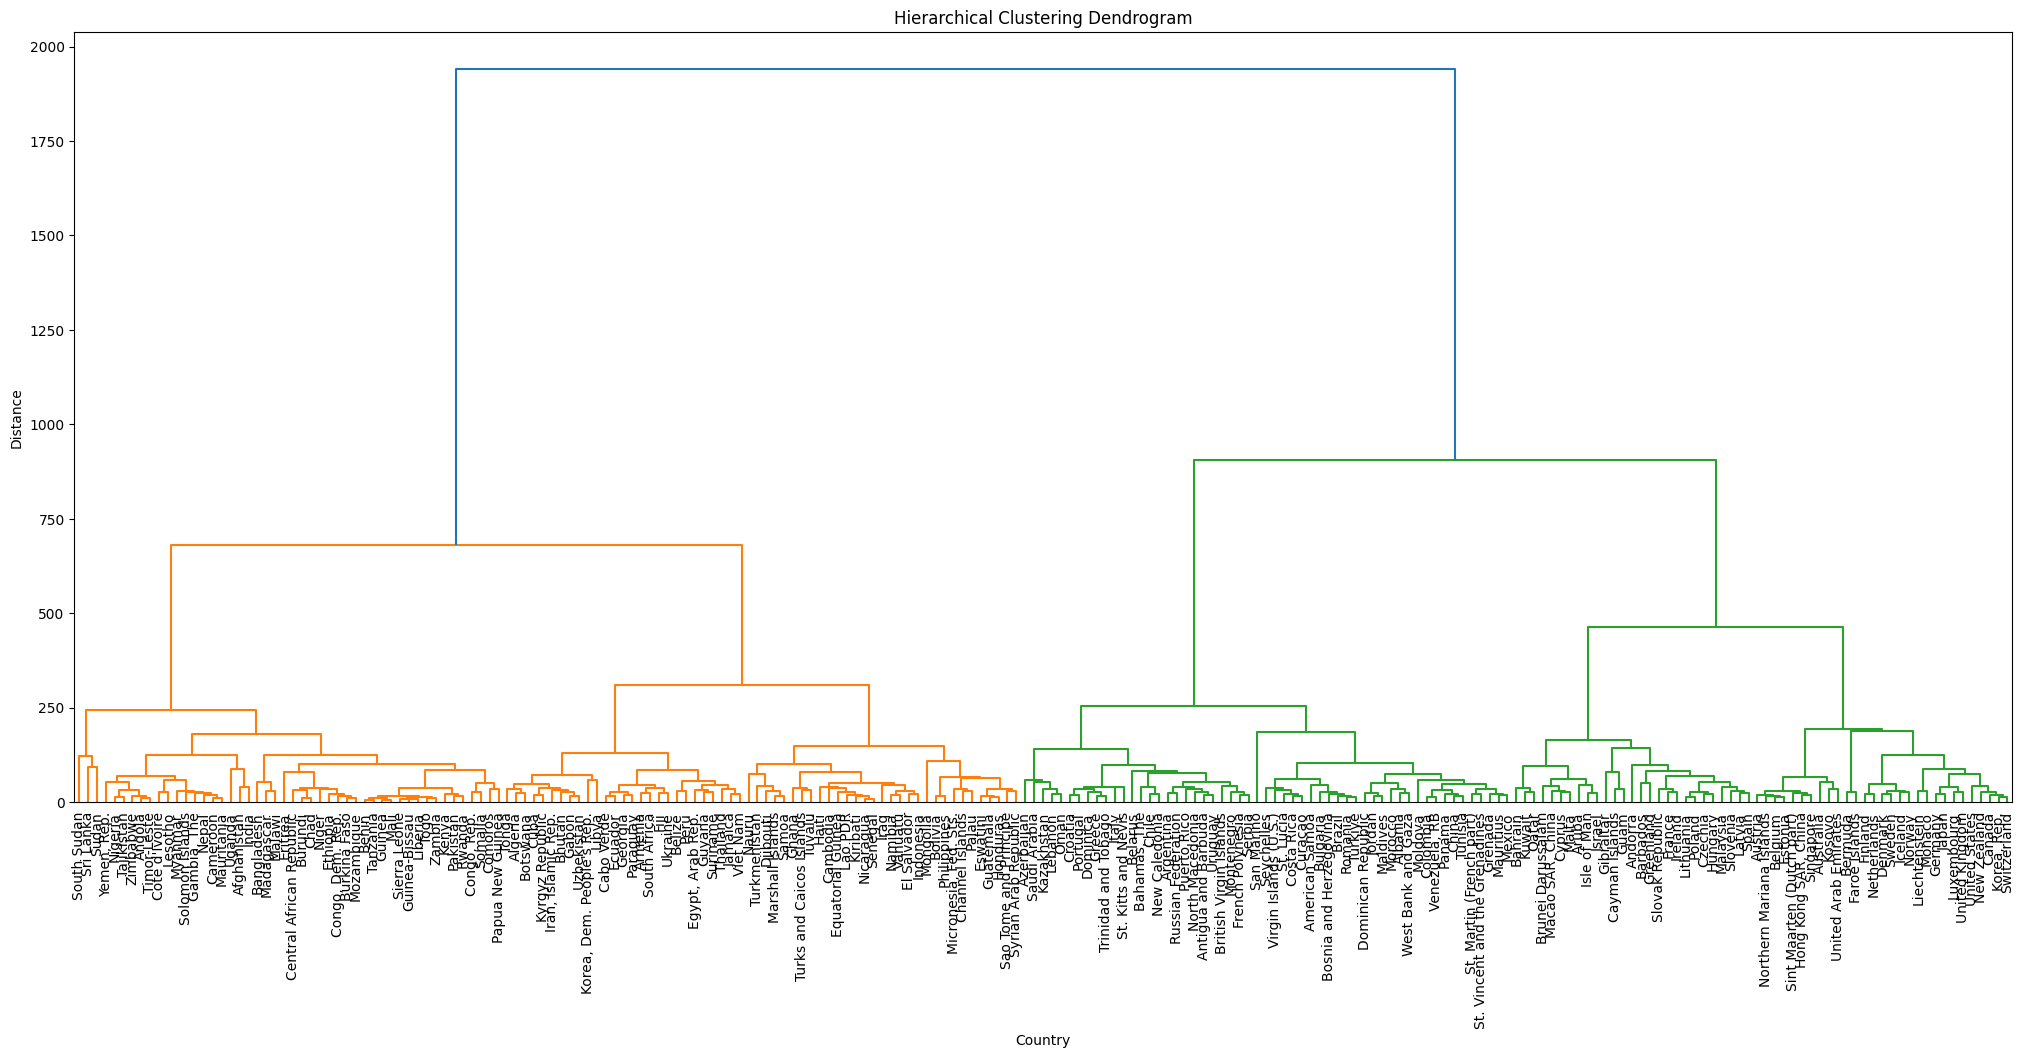

In [79]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Create a linkage matrix using hierarchical clustering
mergings = linkage(samples, method='ward')
# Ward’s method minimizes the variance within clusters. It merges the two clusters that lead to the smallest increase in the sum of squared deviations within all clusters.
# Often results in balanced, compact clusters, and is sensitive to outliers.

# Plot the dendrogram
plt.figure(figsize=(25, 10))
dendrogram(mergings, labels=data_clean.index, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Country')
plt.ylabel('Distance')
# plt.savefig('images/Hierarchical Clustering Dendrogram.png', dpi=300)
plt.show()

- > The dendrogram analysis identified about 4 distinct clusters of countries with similar internet usage patterns, highlighting the global digital divide

## 3. t-SNE

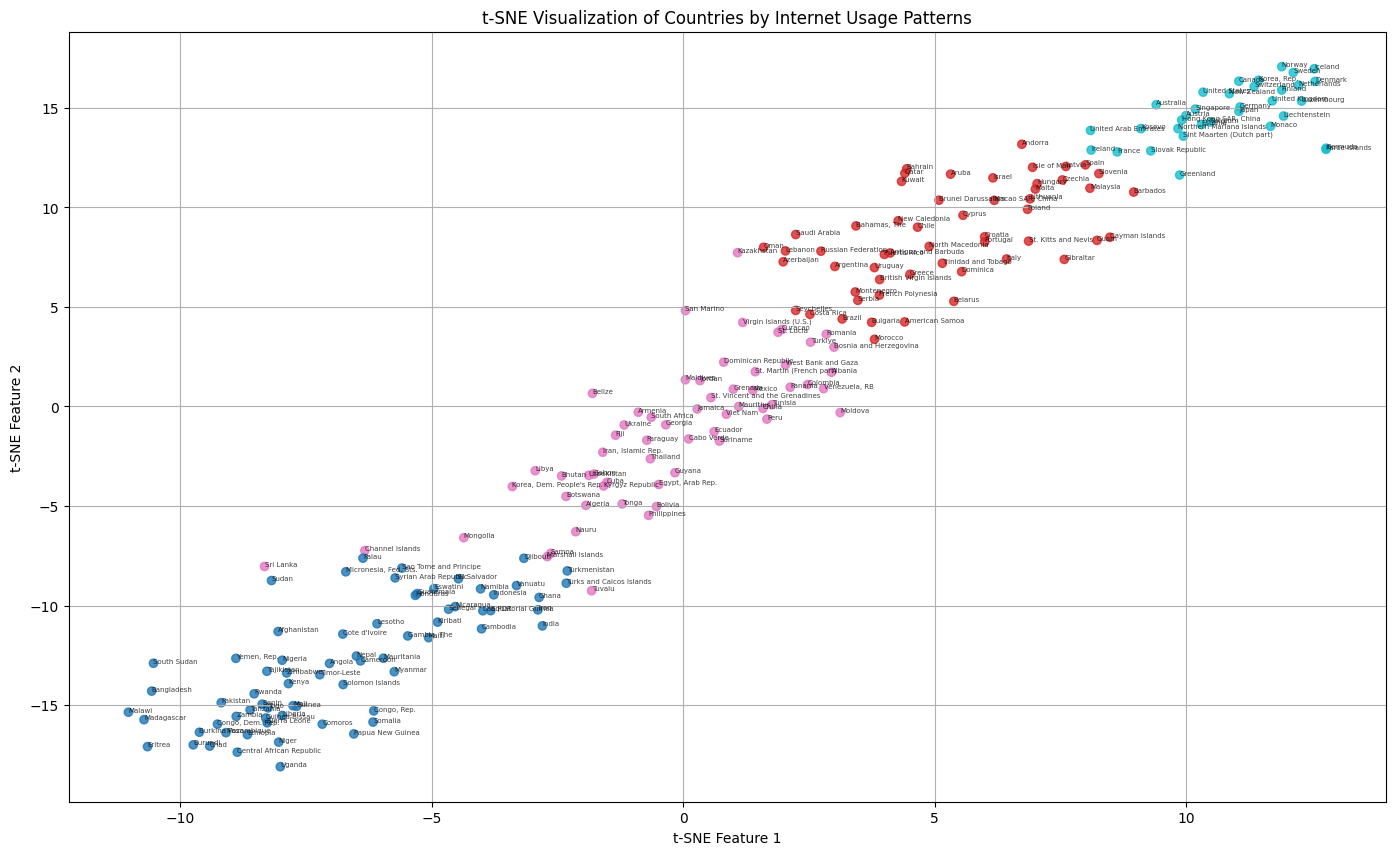

In [80]:
from sklearn.manifold import TSNE

# Fit t-SNE to reduce dimensionality for visualization
model = TSNE(learning_rate=100)
tsne_features = model.fit_transform(samples)

# Extract x and y coordinates
xs = tsne_features[:, 0]
ys = tsne_features[:, 1]

plt.figure(figsize=(17, 10))
# Scatter plot with cluster labels as colors
plt.scatter(xs, ys, c=labels, alpha=0.8, cmap='tab10')

# Annotate each point with the country name (small font for clarity)
for x, y, country in zip(xs, ys, data_clean.index):
    plt.annotate(country, (x, y), fontsize=5, alpha=0.75)

plt.title('t-SNE Visualization of Countries by Internet Usage Patterns')
plt.xlabel('t-SNE Feature 1')
plt.ylabel('t-SNE Feature 2')
plt.grid(True)

# Save the figure with high quality in the images folder
# plt.savefig('images/tsne_internet_usage.png', dpi=300, bbox_inches='tight')
plt.show()

# Enhanced Visualization with Plotly (Interactive)

### Plotly allows you to create interactive visualizations that can enhance your submission.

### Choropleth Map (Internet Usage by Country)

In [ ]:
import plotly.express as px

# Melt the data to have 'Country Name', 'Year', and 'Internet Usage' in separate columns
data_melted = data_clean.reset_index().melt(id_vars=["Country Name"], var_name="Year", value_name="Internet Usage")

# Create an animated choropleth map of internet usage by country over time
fig = px.choropleth(data_melted, 
                    locations="Country Name", 
                    locationmode="country names", 
                    color="Internet Usage", 
                    hover_name="Country Name", 
                    color_continuous_scale="Viridis",
                    animation_frame="Year",  # Set the year column for animation
                    title="Internet Usage by Country (2000-2023)")

# Show the figure
fig.show()


# Executive Summary 

Internet usage has increased globally from <10% in 2000 to ~90% in 2023 in developed countries.

African countries still lag behind with limited access.

Cluster analysis shows three key country types:

High adoption (e.g., USA, UK)

Rapid growth (e.g., India, China)

Low/stagnant growth (e.g., Niger, Chad)

These insights can inform digital infrastructure investment and policy focus areas.

